In [1]:
# Imports to enable plotting functionality
import numpy as np
import matplotlib.pyplot as plt
import bz2
import pickle
import _pickle as cPickle
import os 

from scipy.optimize import leastsq

## functions to enable loading of the pickle files

In [2]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

def findData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        
    return currents,thresholds

def findInitData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []
    init_seg = []
    init_time = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        init_seg.append(data[2])
        init_time.append(data[3])
        
    return currents,thresholds,init_seg,init_time

def truncate_lists(X, Y, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    return X_truncated, Y_truncated

def truncate_lists_init(X, Y, S, T, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    S_truncated = [s for s, y in zip(S, Y) if np.abs(y) >= threshold]
    T_truncated = [t for t, y in zip(T, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    
    return X_truncated, Y_truncated, S_truncated, T_truncated

## Load data for a specific electrode pair location

In [3]:
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/nonlinearity/rot0_25.0_20.0/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/nonlinearity/rot0_-65.0_10.0/'
dir_path = '/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_final/rot0_-160.0_0.0/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig3_yOffset_30/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/nonlinearity_v4_vertical/rot0_-90.0_0.0/'

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
spikes = []
init_segs = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        curr1 = round(float(file.split('_')[0]),2)
        curr2 = round(float(file.split('_')[1][:-9]),2)
        if curr1 < 4 and curr1 > -4 and curr2 < 4 and curr2 > -4:
            i1.append(round(float(file.split('_')[0]),2))
            i2.append(round(float(file.split('_')[1][:-9]),2))
            spikes.append(data[0])
            init_segs.append(data[1])

Electrodes:  [[-175 0 42]
 [-145 0 42]]


In [4]:
print(i1)

[1.41, 1.35, 1.0, 1.43, 1.12, 1.24, 1.42, 1.46, 1.38, 1.46]


In [5]:
print(len(i1),len(i2),len(spikes))

10 10 10


In [6]:
print(spikes)

[0, 1, 1, 0, 1, 1, 0, 0, 0, 0]


## Plot activation region

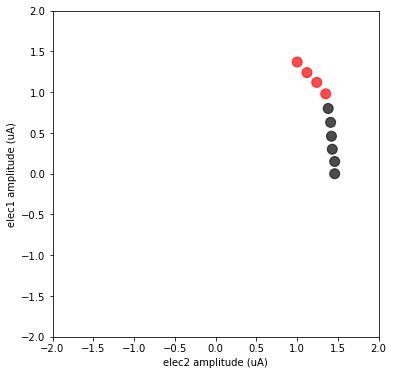

In [7]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

# Create color_map from spikes where spikes=1 is red and spikes=0 is black
color_map = ['black' if x == 0 else 'red' for x in spikes] 


sc = ax.scatter(i1,i2,c=color_map,s=100,alpha=0.7)
# sc = ax.scatter(i1,i2,c=COM,cmap=custom_cmap,vmin=vmin,vmax=vmax,s=100,alpha=1)

ax.set_aspect('equal')
ax.set_xlabel('elec2 amplitude (uA)')
ax.set_ylabel('elec1 amplitude (uA)')
# ax.set_ylabel('Secondary electrode current (uA)')
# ax.set_xlim(-0.01,1.8)
# ax.set_ylim(-0.01,1.8)
# ax.set_xlim(-7,7)
# ax.set_ylim(-7,7)
ax.set_xlim(-2,2)
ax.set_ylim(-2,2)

fig.savefig('linear_data.pdf', bbox_inches='tight')

## Try to fit an ellipse to the raw data

In [8]:
def fit_ellipse(x, y):
    x = x[:, np.newaxis]
    y = y[:, np.newaxis]
    D = np.hstack((x * x, x * y, y * y, x, y, np.ones_like(x)))
    S = np.dot(D.T, D)
    C = np.zeros([6, 6])
    C[0, 2] = C[2, 0] = 2
    C[1, 1] = -1
    E, V = np.linalg.eig(np.dot(np.linalg.inv(S), C))
    n = np.argmax(np.abs(E))
    a = V[:, n]
    return a

def ellipse_center(a):
    b, c, d, f, g, a = a[1] / 2, a[2], a[3] / 2, a[4] / 2, a[5], a[0]
    num = b * b - a * c
    x0 = (c * d - b * f) / num
    y0 = (a * f - b * d) / num
    return np.array([x0, y0])

def ellipse_axis_length(a):
    b, c, d, f, g, a = a[1] / 2, a[2], a[3] / 2, a[4] / 2, a[5], a[0]
    up = 2 * (a * f * f + c * d * d + g * b * b - 2 * b * d * f - a * c * g)
    down1 = (b * b - a * c) * ((c - a) * np.sqrt(1 + 4 * b * b / ((a - c) * (a - c))) - (c + a))
    down2 = (b * b - a * c) * ((a - c) * np.sqrt(1 + 4 * b * b / ((a - c) * (a - c))) - (c + a))
    res1 = np.sqrt(np.abs(up / down1))
    res2 = np.sqrt(np.abs(up / down2))
    return np.array([res1, res2])

def ellipse_angle_of_rotation(a):
    b, c, d, f, g, a = a[1] / 2, a[2], a[3] / 2, a[4] / 2, a[5], a[0]
    return 0.5 * np.arctan(2 * b / (a - c))

def plot_ellipse(center, axes, angle, ax):
    t = np.linspace(0, 2 * np.pi, 100)
    Ell = np.array([axes[0] * np.cos(t), axes[1] * np.sin(t)])
    R_rot = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
    Ell_rot = np.dot(R_rot, Ell)
    ax.plot(center[0] + Ell_rot[0, :], center[1] + Ell_rot[1, :], 'k--')
    
    # Plot major and minor axes
    major_axis_x = [center[0] - axes[0] * np.cos(angle), center[0] + axes[0] * np.cos(angle)]
    major_axis_y = [center[1] - axes[0] * np.sin(angle), center[1] + axes[0] * np.sin(angle)]
    minor_axis_x = [center[0] - axes[1] * np.sin(angle), center[0] + axes[1] * np.sin(angle)]
    minor_axis_y = [center[1] + axes[1] * np.cos(angle), center[1] - axes[1] * np.cos(angle)]
    
    ax.plot(major_axis_x, major_axis_y, 'b-')
    ax.plot(minor_axis_x, minor_axis_y, 'g-')


No handles with labels found to put in legend.


Major axis length: 0.05185880094595337
Minor axis length: 0.0172612473537938


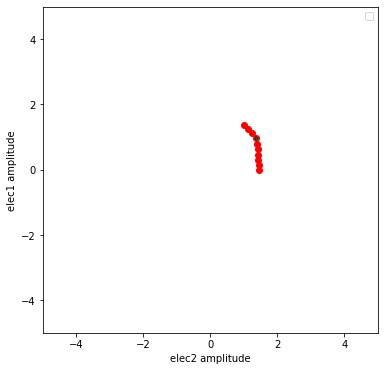

In [9]:
# Fit ellipse
x = np.array(i1)
y = np.array(i2)

# Fit ellipse
a = fit_ellipse(x, y)
center = ellipse_center(a)
axes = ellipse_axis_length(a)
angle = ellipse_angle_of_rotation(a)

# Determine major and minor axes lengths
major_axis_length = max(axes)
minor_axis_length = min(axes)

# Plot data and ellipse

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111)

ax.scatter(x, y, color='r')
plot_ellipse(center, axes, angle, ax)
ax.legend()
ax.set_xlabel('elec2 amplitude')
ax.set_ylabel('elec1 amplitude')
# ax.set_title('2D Ellipse Fitting')
ax.set_xlim([-5,5])
ax.set_ylim([-5,5])

# Print lengths of major and minor axes
print(f"Major axis length: {major_axis_length}")
print(f"Minor axis length: {minor_axis_length}")

fig.savefig('linear_fit.pdf', bbox_inches='tight')

In [10]:
axes_ratio = major_axis_length/minor_axis_length
print(axes_ratio)

3.004348404436454


In [11]:
electrodes = []
spacing_x = 5
start_x = -210
end_x = 80
spacing_y = 5
start_y = -60
end_y = 5

x_loc = np.arange(start_x,end_x,spacing_x)
y_loc = np.arange(start_y,end_y,spacing_y)

for x in x_loc:
    for y in y_loc:
        electrodes.append([[x-15, y, 42],[x+15, y, 42]])


In [12]:
print(len(electrodes))
print(electrodes)

754
[[[-225, -60, 42], [-195, -60, 42]], [[-225, -55, 42], [-195, -55, 42]], [[-225, -50, 42], [-195, -50, 42]], [[-225, -45, 42], [-195, -45, 42]], [[-225, -40, 42], [-195, -40, 42]], [[-225, -35, 42], [-195, -35, 42]], [[-225, -30, 42], [-195, -30, 42]], [[-225, -25, 42], [-195, -25, 42]], [[-225, -20, 42], [-195, -20, 42]], [[-225, -15, 42], [-195, -15, 42]], [[-225, -10, 42], [-195, -10, 42]], [[-225, -5, 42], [-195, -5, 42]], [[-225, 0, 42], [-195, 0, 42]], [[-220, -60, 42], [-190, -60, 42]], [[-220, -55, 42], [-190, -55, 42]], [[-220, -50, 42], [-190, -50, 42]], [[-220, -45, 42], [-190, -45, 42]], [[-220, -40, 42], [-190, -40, 42]], [[-220, -35, 42], [-190, -35, 42]], [[-220, -30, 42], [-190, -30, 42]], [[-220, -25, 42], [-190, -25, 42]], [[-220, -20, 42], [-190, -20, 42]], [[-220, -15, 42], [-190, -15, 42]], [[-220, -10, 42], [-190, -10, 42]], [[-220, -5, 42], [-190, -5, 42]], [[-220, 0, 42], [-190, 0, 42]], [[-215, -60, 42], [-185, -60, 42]], [[-215, -55, 42], [-185, -55, 42]],

## March through dir, extract nonlinearity of different electrode locs

In [40]:
nonlinearity_list = []
electrode_center_list = []

parent_dir = '/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_final_v2/'
# parent_dir = '/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_v2/'
# parent_dir = '/Volumes/Scratch/Users/vilkhu/sim-data/nonlinearity/'

# Loop through all sub directories in parent_dir
for sub_dir in os.listdir(parent_dir):
    dir_path = parent_dir+sub_dir+'/'
    print(dir_path)
    
    # Output the electrodes files 
    filename = dir_path+'electrodes.pkl'
    elecs = decompress_pickle(filename)
    print('Electrodes: ',elecs)

    # Find data files in dir
    data_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if '_' in file:
                data_files.append(file)

    # Next, extract data
    i1 = []
    i2 = []
    spikes = []
    init_segs = []
    for file in data_files:
            filename = dir_path+str(file)
            data = decompress_pickle(filename[:-5])

            # Output substring before '_' in file
            curr1 = round(float(file.split('_')[0]),2)
            curr2 = round(float(file.split('_')[1][:-9]),2)
            if curr1 < 6 and curr1 > -6 and curr2 < 6 and curr2 > -6:
                i1.append(round(float(file.split('_')[0]),2))
                i2.append(round(float(file.split('_')[1][:-9]),2))
                spikes.append(data[0])
                init_segs.append(data[1])


    print(len(i1),len(i2),len(spikes))

    if len(i1) <= 5 or len(i2) <= 5:
        nonlinearity_list.append(-1) # 100
        elec1 = elecs[0]
        elec2 = elecs[1]
        elec_center = [(elec1[0]+elec2[0])/2, (elec1[1]+elec2[1])/2]
        electrode_center_list.append(elec_center)
    else:
        # Fit and plot an ellipse to the data
        x = np.array(i1)
        y = np.array(i2)

        # Fit ellipse
        a = fit_ellipse(x, y)
        center = ellipse_center(a)
        axes = ellipse_axis_length(a)
        angle = ellipse_angle_of_rotation(a)

        # Determine major and minor axes lengths
        major_axis_length = max(axes)
        minor_axis_length = min(axes)

        # Print lengths of major and minor axes
        print(f"Major axis length: {major_axis_length}")
        print(f"Minor axis length: {minor_axis_length}")

        nonlinearity = major_axis_length/minor_axis_length
        print('Axes ratio: ',nonlinearity)

        # Save data
        nonlinearity_list.append(nonlinearity)
        elec1 = elecs[0]
        elec2 = elecs[1]
        elec_center = [(elec1[0]+elec2[0])/2, (elec1[1]+elec2[1])/2]
        electrode_center_list.append(elec_center)
        print(elec_center)

        # # Plot data and ellipse
        # fig = plt.figure(figsize=(6,6))
        # ax = fig.add_subplot(111)
        # ax.scatter(x, y, label='Data points')
        # plot_ellipse(center, axes, angle, ax)
        # ax.legend()
        # ax.set_aspect('equal')
        # ax.set_xlabel('Primary electrode current (uA)')
        # ax.set_ylabel('Secondary electrode current (uA)')

        # plt.show()


/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_final_v2/rot0_-5.0_0.0/
Electrodes:  [[-20 0 42]
 [10 0 42]]
30 30 30
Major axis length: 5.135427816585896
Minor axis length: 1.3056459741199233
Axes ratio:  3.9332467746836612
[-5.0, 0.0]
/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_final_v2/rot0_20.0_-70.0/
Electrodes:  [[5 -70 42]
 [35 -70 42]]
0 0 0
/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_final_v2/rot0_70.0_-15.0/
Electrodes:  [[55 -15 42]
 [85 -15 42]]
0 0 0
/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_final_v2/rot0_-50.0_-80.0/
Electrodes:  [[-65 -80 42]
 [-35 -80 42]]
2 2 2
/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_final_v2/rot0_55.0_-10.0/
Electrodes:  [[40 -10 42]
 [70 -10 42]]
4 4 4
/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_final_v2/rot0_-135.0_-50.0/
Electrodes:  [[-150 -50 42]
 [-120 -50 42]]
0 0 0
/Volumes/Lab/Users/vilkhu/data-backup/nonlinearity_final_v2/rot0_-60.0_-10.0/
Electrodes:  [[-75 -10 42]
 [-45 -10 42]]
30 30 30
Major ax

In [41]:
print(len(nonlinearity_list))
print(len(electrode_center_list))

592
592


In [42]:
print(nonlinearity_list)

[3.9332467746836612, -1, -1, -1, -1, -1, 1.606024763021827, 3.644701874755815, -1, 2.2420574964281896, 2.3629297318791567, -1, 1.4508312343856724, 4.097184428838049, 1.3010645839793944, 4.836980381480867, 1.8502144053343799, 7.497469420804495, 5.135904318743082, 2.285734277901034, 2.681571496584136, 3.181989038746995, 2.3955434928594075, 3.477351091349341, 2.6092586863506804, 3.47671267737295, -1, 3.1538759194968002, -1, -1, 5.361592548705839, 3.0117437855402738, 4.16336975191693, -1, -1, -1, 4.750234669839651, 4.8046526475664955, 2.852935203066663, 1.9927197614357999, 5.377715269656269, 4.100067767023074, -1, 4.531174788790052, -1, 2.3028238097118443, -1, 3.3796417175722775, 1.042685810259375, 4.348377173961995, 2.16838957719592, 2.5734232902512364, 6.842826805041237, -1, 2.8074799709748897, -1, 2.899710940107938, 2.4973691140207084, 1.2850066972813061, 2.8099166068954857, 2.8858694857740215, 2.735465354731567, 3.6440249045112467, -1, 3.1201068350878494, 1.0903922456528032, 1.58839295

In [43]:
print(nonlinearity)

1.8533480653649232


In [44]:
full_data_nonlinearity = []
full_data_electrode_center = []

for ii,elec in enumerate(electrode_center_list):
    # if elec[1] > -42 and elec[1] < 42:
    full_data_nonlinearity.append(nonlinearity_list[ii])
    full_data_electrode_center.append(elec)
    elec_mirror = [elec[0],-elec[1]]
    full_data_nonlinearity.append(nonlinearity_list[ii])
    full_data_electrode_center.append(elec_mirror)


In [45]:
print(len(full_data_electrode_center))

1184


In [46]:
from matplotlib.colors import Normalize
from scipy.interpolate import griddata

In [47]:
print(electrode_center_list)

[[-5.0, 0.0], [20.0, -70.0], [70.0, -15.0], [-50.0, -80.0], [55.0, -10.0], [-135.0, -50.0], [-60.0, -10.0], [0.0, -55.0], [-150.0, -40.0], [-90.0, -10.0], [-100.0, -25.0], [-30.0, -75.0], [-140.0, -30.0], [-70.0, -60.0], [-125.0, -20.0], [-80.0, -60.0], [-45.0, -15.0], [-110.0, -55.0], [-95.0, -40.0], [-35.0, -25.0], [-50.0, -35.0], [-65.0, -40.0], [-75.0, 0.0], [-85.0, -30.0], [-40.0, -45.0], [-75.0, -30.0], [-120.0, -70.0], [-10.0, -20.0], [10.0, -55.0], [75.0, -45.0], [25.0, -20.0], [-5.0, -50.0], [40.0, -30.0], [65.0, -35.0], [50.0, -40.0], [35.0, -50.0], [40.0, -20.0], [25.0, -30.0], [-5.0, -40.0], [-70.0, -5.0], [40.0, -5.0], [10.0, -45.0], [-100.0, -80.0], [35.0, -40.0], [50.0, -50.0], [-30.0, -5.0], [65.0, -25.0], [-65.0, -50.0], [-130.0, -10.0], [5.0, -15.0], [-50.0, -25.0], [-35.0, -35.0], [-95.0, -50.0], [75.0, 0.0], [-10.0, -30.0], [-120.0, -60.0], [-75.0, -20.0], [-25.0, -45.0], [-115.0, -15.0], [-40.0, -55.0], [-85.0, -20.0], [-30.0, -65.0], [-100.0, -35.0], [-150.0, -50.

In [48]:
# Load in dendrites to plot
with open('/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/plotting/dend_compartments.pkl','rb') as f:
    dend_compartments = pickle.load(f)

In [49]:
print(full_data_nonlinearity)

# Save nonlinearity = 1/full_data_nonlinearity
nonlinearity = [1/x for x in full_data_nonlinearity]

[3.9332467746836612, 3.9332467746836612, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 1.606024763021827, 1.606024763021827, 3.644701874755815, 3.644701874755815, -1, -1, 2.2420574964281896, 2.2420574964281896, 2.3629297318791567, 2.3629297318791567, -1, -1, 1.4508312343856724, 1.4508312343856724, 4.097184428838049, 4.097184428838049, 1.3010645839793944, 1.3010645839793944, 4.836980381480867, 4.836980381480867, 1.8502144053343799, 1.8502144053343799, 7.497469420804495, 7.497469420804495, 5.135904318743082, 5.135904318743082, 2.285734277901034, 2.285734277901034, 2.681571496584136, 2.681571496584136, 3.181989038746995, 3.181989038746995, 2.3955434928594075, 2.3955434928594075, 3.477351091349341, 3.477351091349341, 2.6092586863506804, 2.6092586863506804, 3.47671267737295, 3.47671267737295, -1, -1, 3.1538759194968002, 3.1538759194968002, -1, -1, -1, -1, 5.361592548705839, 5.361592548705839, 3.0117437855402738, 3.0117437855402738, 4.16336975191693, 4.16336975191693, -1, -1, -1, -1, -1, -1, 4.750

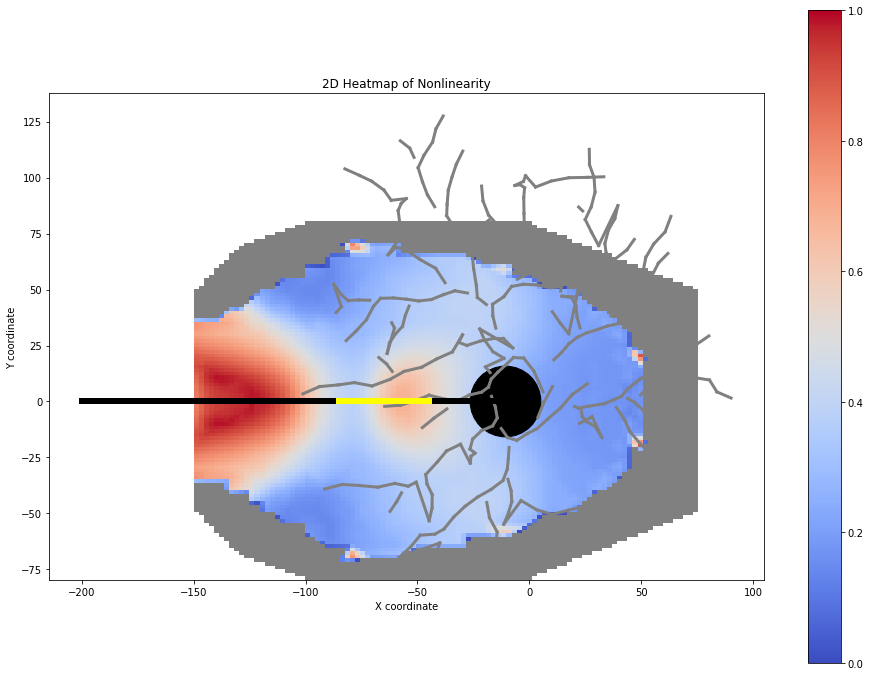

In [50]:
# Extract x and y coordinates
x_coords, y_coords = zip(*full_data_electrode_center)

# # Filter x and y coords to be in a certain range
# x_coords_filtered = []
# y_coords_filtered = []
# for ii,elec in enumerate(full_data_electrode_center):
#     if (elec[1] > -42 and elec[1] < 42) and (elec[0] > -190 and elec[0] < 40):
#         x_coords_filtered.append(elec[0])
#         y_coords_filtered.append(elec[1])

# x_coords = x_coords_filtered
# y_coords = y_coords_filtered

# Define the grid to interpolate the values
grid_x, grid_y = np.mgrid[min(x_coords):max(x_coords):100j, min(y_coords):max(y_coords):100j]

# Interpolate nonlinearity values onto the grid
# grid_z = griddata(full_data_electrode_center, full_data_nonlinearity, (grid_x, grid_y), method='linear')
grid_z = griddata(full_data_electrode_center, nonlinearity, (grid_x, grid_y), method='linear')

# Plot the heatmap
fig = plt.figure(figsize=(16,12))
ax = fig.add_subplot(111)
# norm = Normalize(vmin=1, vmax=3)
norm = Normalize(vmin=0, vmax=1)
ax.imshow(grid_z.T, extent=(min(x_coords), max(x_coords), min(y_coords), max(y_coords)), origin='lower', cmap='coolwarm', norm=norm)
# Show the colorbar
cbar = plt.colorbar(ax.imshow(grid_z.T, extent=(min(x_coords), max(x_coords), min(y_coords), max(y_coords)), origin='lower', cmap='coolwarm', norm=norm))
# ax.scatter(x_coords, y_coords, c='black', marker='x')  # Mark the electrode centers
ax.set_title('2D Heatmap of Nonlinearity')
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
# ax.set_xlim([-180,20])
# ax.set_ylim([-40,40])
# ax.set_xlim([-120,20])
# ax.set_ylim([-50,50])



# Plot dend compartments
last_coord = []
notFirst = False
for dend_x,dend_y in dend_compartments:
    # ax.scatter(dend_x,dend_y,color='red')
    if notFirst:
        # If distance between last_coord[-1] and dend_x[0] is less than 20, connect them
        if np.sqrt((last_coord[-1][0]-dend_x[0])**2 + (last_coord[-1][1]-dend_y[0])**2) < 20:
            ax.plot([last_coord[-1][0],dend_x[0]],[last_coord[-1][1],dend_y[0]],color='grey',linewidth=3)
    for i in range(len(dend_x)-1):
        ax.plot([dend_x[i],dend_x[i+1]],[dend_y[i],dend_y[i+1]],color='grey',linewidth=3)
    # Save last coord
    last_coord.append([dend_x[-1],dend_y[-1]])
    notFirst = True

# Add a ball and stick to this figure
# Ball
ax.scatter(-11, 0, c='black', marker='o', s=5000)
# Line
ax.plot([-200, -11], [0, 0], c='black', linewidth=6)
ax.plot([-45, -85], [0, 0], c='yellow', linewidth=6)


plt.show()

# Save figure 
# fig.savefig('nonlinearity_heatmap.pdf', bbox_inches='tight')

## Filter the data such that there is a new color that represents inactivation

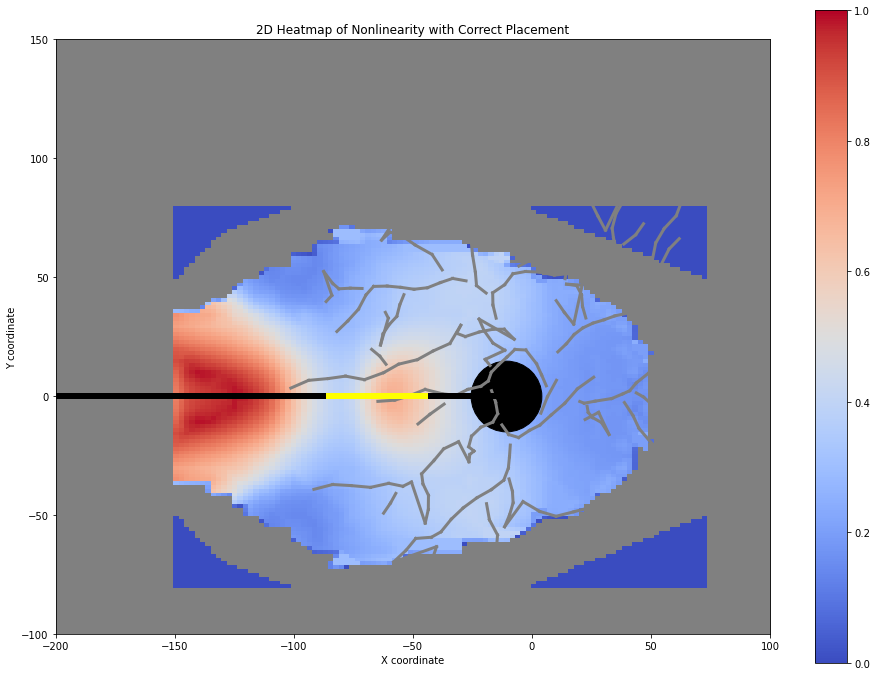

In [53]:
# Extract x and y coordinates
x_coords, y_coords = zip(*full_data_electrode_center)

# Define new grid range covering the larger extent
new_grid_x, new_grid_y = np.mgrid[-200:100:134j, -100:150:156j]

# Old grid extents
old_min_x, old_max_x = -150, 75
old_min_y, old_max_y = -80, 80

# Create new grid_z initialized with zeros
new_grid_z = np.zeros_like(new_grid_x) - 1

# Create old grid for the data
old_grid_x, old_grid_y = np.mgrid[old_min_x:old_max_x:100j, old_min_y:old_max_y:100j]
old_grid_z = griddata(full_data_electrode_center, nonlinearity, (old_grid_x, old_grid_y), method='linear', fill_value=0)

# Calculate step size for new grid
x_step = (new_grid_x[1, 0] - new_grid_x[0, 0])
y_step = (new_grid_y[0, 1] - new_grid_y[0, 0])

# Calculate starting indices for placement based on new grid range
x_start = int((old_min_x - new_grid_x[0, 0]) / x_step)
y_start = int((old_min_y - new_grid_y[0, 0]) / y_step)

# Calculate ending indices
x_end = x_start + old_grid_z.shape[0]
y_end = y_start + old_grid_z.shape[1]

# Ensure indices are within valid boundaries
x_end = min(new_grid_z.shape[0], x_end)
y_end = min(new_grid_z.shape[1], y_end)

# Trim old data if it exceeds new grid boundaries
trim_x = x_end - x_start
trim_y = y_end - y_start
old_grid_z = old_grid_z[:trim_x, :trim_y]

# Place old data within the specified region
new_grid_z[x_start:x_end, y_start:y_end] = old_grid_z

# Define the center point and threshold distance
center_x, center_y = -10, 0
threshold_distance = 50

# Calculate the radial distance for each point in the grid from the center (-10, 0)
distances = np.sqrt((new_grid_x - center_x)**2 + (new_grid_y - center_y)**2)

# Apply the condition: distance > 50 and x > 0
mask = (distances > threshold_distance) & (new_grid_x > 0)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.25)] = 0.20

# Apply the condition: y > 50
mask = (new_grid_y > 50)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.4)] = 0.4

# Apply the condition: y > 50
mask = (new_grid_y < -50)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.4)] = 0.4

# Apply the condition: y > 50
mask = (new_grid_y > 60)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.3)] = 0.3

# Apply the condition: y > 50
mask = (new_grid_y < -60)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.3)] = 0.3

# Plot the heatmap on the new grid
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
norm = Normalize(vmin=0, vmax=1)
heatmap = ax.imshow(new_grid_z.T, extent=(new_grid_x.min(), new_grid_x.max(), new_grid_y.min(), new_grid_y.max()),
                    origin='lower', cmap='coolwarm', norm=norm)
# Show the colorbar
cbar = plt.colorbar(heatmap)
ax.set_title('2D Heatmap of Nonlinearity with Correct Placement')
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
# ax.set_xlim([-120,20])
# ax.set_ylim([-50,50])


# Plot dend compartments
last_coord = []
notFirst = False
for dend_x,dend_y in dend_compartments:
    # ax.scatter(dend_x,dend_y,color='red')
    if notFirst:
        # If distance between last_coord[-1] and dend_x[0] is less than 20, connect them
        if np.sqrt((last_coord[-1][0]-dend_x[0])**2 + (last_coord[-1][1]-dend_y[0])**2) < 20:
            ax.plot([last_coord[-1][0],dend_x[0]],[last_coord[-1][1],dend_y[0]],color='grey',linewidth=3)
    for i in range(len(dend_x)-1):
        ax.plot([dend_x[i],dend_x[i+1]],[dend_y[i],dend_y[i+1]],color='grey',linewidth=3)
    # Save last coord
    last_coord.append([dend_x[-1],dend_y[-1]])
    notFirst = True

# Add a ball and stick to this figure
# Ball
ax.scatter(-11, 0, c='black', marker='o', s=5000)
# Line
ax.plot([-200, -11], [0, 0], c='black', linewidth=6)
ax.plot([-45, -85], [0, 0], c='yellow', linewidth=6)

plt.show()

# Save figure 
fig.savefig('nonlinearity_heatmap_NEW.pdf', bbox_inches='tight')

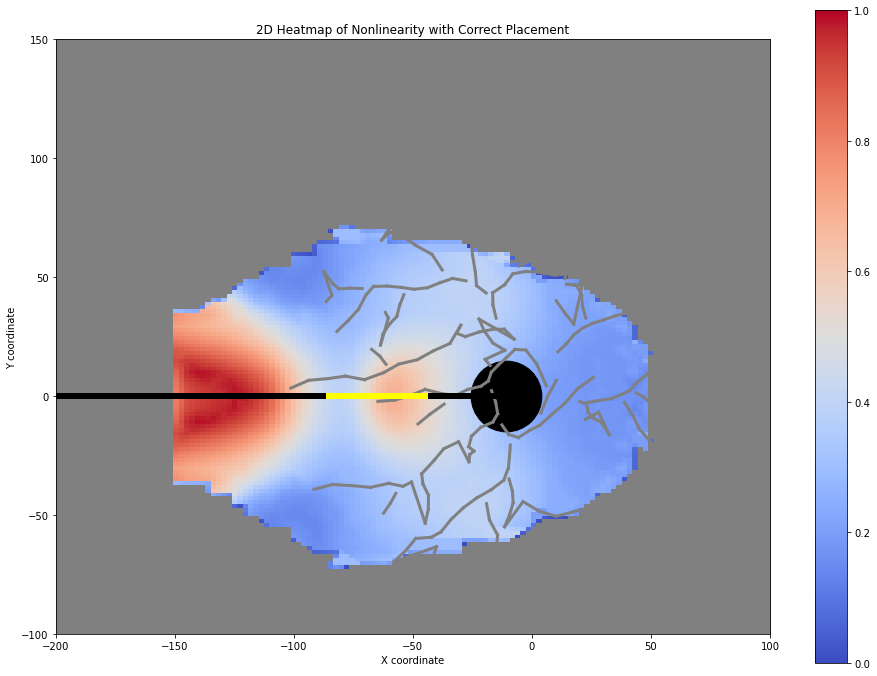

In [57]:
# Extract x and y coordinates
x_coords, y_coords = zip(*full_data_electrode_center)

# Define new grid range covering the larger extent
new_grid_x, new_grid_y = np.mgrid[-200:100:134j, -100:150:156j]

# Old grid extents
old_min_x, old_max_x = -150, 75
old_min_y, old_max_y = -80, 80

# Create new grid_z initialized with zeros
new_grid_z = np.zeros_like(new_grid_x) - 1

# Create old grid for the data
old_grid_x, old_grid_y = np.mgrid[old_min_x:old_max_x:100j, old_min_y:old_max_y:100j]
old_grid_z = griddata(full_data_electrode_center, nonlinearity, (old_grid_x, old_grid_y), method='linear', fill_value=-1)

# Calculate step size for new grid
x_step = (new_grid_x[1, 0] - new_grid_x[0, 0])
y_step = (new_grid_y[0, 1] - new_grid_y[0, 0])

# Calculate starting indices for placement based on new grid range
x_start = int((old_min_x - new_grid_x[0, 0]) / x_step)
y_start = int((old_min_y - new_grid_y[0, 0]) / y_step)

# Calculate ending indices
x_end = x_start + old_grid_z.shape[0]
y_end = y_start + old_grid_z.shape[1]

# Ensure indices are within valid boundaries
x_end = min(new_grid_z.shape[0], x_end)
y_end = min(new_grid_z.shape[1], y_end)

# Trim old data if it exceeds new grid boundaries
trim_x = x_end - x_start
trim_y = y_end - y_start
old_grid_z = old_grid_z[:trim_x, :trim_y]

# Place old data within the specified region
new_grid_z[x_start:x_end, y_start:y_end] = old_grid_z

# Define the center point and threshold distance
center_x, center_y = -10, 0
threshold_distance = 50

# Calculate the radial distance for each point in the grid from the center (-10, 0)
distances = np.sqrt((new_grid_x - center_x)**2 + (new_grid_y - center_y)**2)

# Apply the condition: distance > 50 and x > 0
mask = (distances > threshold_distance) & (new_grid_x > 0)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.25)] = 0.20

# Apply the condition: y > 50
mask = (new_grid_y > 50)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.4)] = 0.4

# Apply the condition: y > 50
mask = (new_grid_y < -50)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.4)] = 0.4

# Apply the condition: y > 50
mask = (new_grid_y > 60)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.3)] = 0.3

# Apply the condition: y > 50
mask = (new_grid_y < -60)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.3)] = 0.3

# Plot the heatmap on the new grid
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
norm = Normalize(vmin=0, vmax=1)
heatmap = ax.imshow(new_grid_z.T, extent=(new_grid_x.min(), new_grid_x.max(), new_grid_y.min(), new_grid_y.max()),
                    origin='lower', cmap='coolwarm', norm=norm)
# Show the colorbar
cbar = plt.colorbar(heatmap)
ax.set_title('2D Heatmap of Nonlinearity with Correct Placement')
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
# ax.set_xlim([-120,20])
# ax.set_ylim([-50,50])


# Plot dend compartments
last_coord = []
notFirst = False
for dend_x,dend_y in dend_compartments:
    # ax.scatter(dend_x,dend_y,color='red')
    if notFirst:
        # If distance between last_coord[-1] and dend_x[0] is less than 20, connect them
        if np.sqrt((last_coord[-1][0]-dend_x[0])**2 + (last_coord[-1][1]-dend_y[0])**2) < 20:
            ax.plot([last_coord[-1][0],dend_x[0]],[last_coord[-1][1],dend_y[0]],color='grey',linewidth=3)
    for i in range(len(dend_x)-1):
        ax.plot([dend_x[i],dend_x[i+1]],[dend_y[i],dend_y[i+1]],color='grey',linewidth=3)
    # Save last coord
    last_coord.append([dend_x[-1],dend_y[-1]])
    notFirst = True

# Add a ball and stick to this figure
# Ball
ax.scatter(-11, 0, c='black', marker='o', s=5000)
# Line
ax.plot([-200, -11], [0, 0], c='black', linewidth=6)
ax.plot([-45, -85], [0, 0], c='yellow', linewidth=6)

plt.show()

# Save figure 
fig.savefig('nonlinearity_heatmap_NEW.pdf', bbox_inches='tight')

In [168]:
# Make a list of relavent bielectrode pairs 
electrodes = []
spacing_x = 10
start_x = -130 # -120, -150
end_x = 30 # 80, -120
spacing_y = 5
start_y = -85
end_y = -70

x_loc = np.arange(start_x,end_x,spacing_x)
y_loc = np.arange(start_y,end_y,spacing_y)

In [169]:
print(x_loc, y_loc)

[-130 -120 -110 -100  -90  -80  -70  -60  -50  -40  -30  -20  -10    0
   10   20] [-85 -80 -75]


/home/vision/anaconda3/envs/vilkhu-py36/lib/python3.6/site-packages/ipykernel_launcher.py:83: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))
/home/vision/anaconda3/envs/vilkhu-py36/lib/python3.6/site-packages/ipykernel_launcher.py:84: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("coolwarm"))


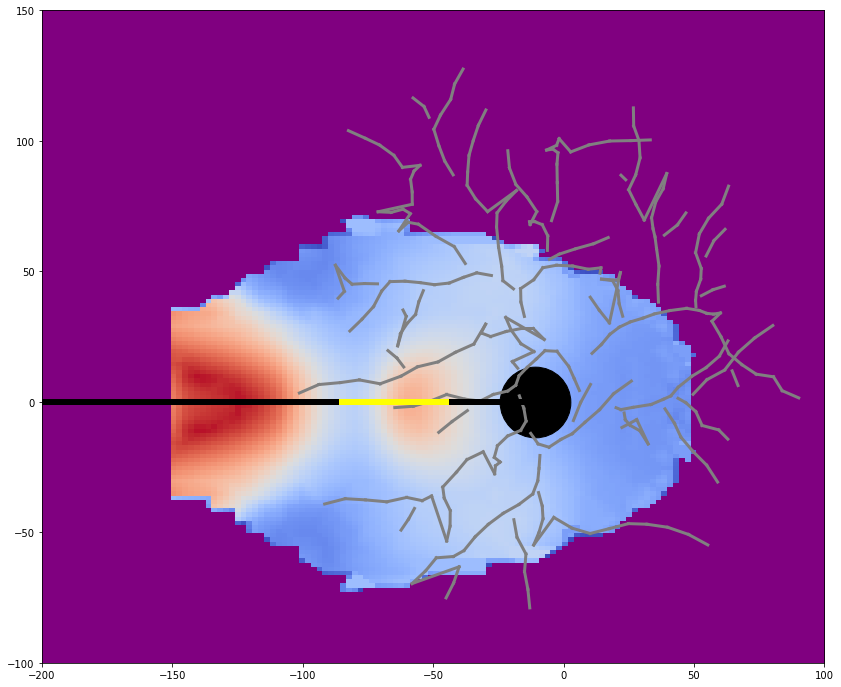

In [61]:
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm

# Extract x and y coordinates
x_coords, y_coords = zip(*full_data_electrode_center)

# Define new grid range covering the larger extent
new_grid_x, new_grid_y = np.mgrid[-200:100:134j, -100:150:156j]

# Old grid extents
old_min_x, old_max_x = -150, 75
old_min_y, old_max_y = -80, 80

# Create new grid_z initialized with zeros
new_grid_z = np.zeros_like(new_grid_x) -1

# Create old grid for the data
old_grid_x, old_grid_y = np.mgrid[old_min_x:old_max_x:100j, old_min_y:old_max_y:100j]
old_grid_z = griddata(full_data_electrode_center, nonlinearity, (old_grid_x, old_grid_y), method='linear', fill_value=-1) # CHANGED fill_value from 0

# Calculate step size for new grid
x_step = (new_grid_x[1, 0] - new_grid_x[0, 0])
y_step = (new_grid_y[0, 1] - new_grid_y[0, 0])

# Calculate starting indices for placement based on new grid range
x_start = int((old_min_x - new_grid_x[0, 0]) / x_step)
y_start = int((old_min_y - new_grid_y[0, 0]) / y_step)

# Calculate ending indices
x_end = x_start + old_grid_z.shape[0]
y_end = y_start + old_grid_z.shape[1]

# Ensure indices are within valid boundaries
x_end = min(new_grid_z.shape[0], x_end)
y_end = min(new_grid_z.shape[1], y_end)

# Trim old data if it exceeds new grid boundaries
trim_x = x_end - x_start
trim_y = y_end - y_start
old_grid_z = old_grid_z[:trim_x, :trim_y]

# Place old data within the specified region
new_grid_z[x_start:x_end, y_start:y_end] = old_grid_z

# Define the center point and threshold distance
center_x, center_y = -10, 0
threshold_distance = 50

# Calculate the radial distance for each point in the grid from the center (-10, 0)
distances = np.sqrt((new_grid_x - center_x)**2 + (new_grid_y - center_y)**2)

# Apply the condition: distance > 50 and x > 0
mask = (distances > threshold_distance) & (new_grid_x > 0)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.25)] = 0.20

# Apply the condition: y > 50
mask = (new_grid_y > 50)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.4)] = 0.4

# Apply the condition: y > 50
mask = (new_grid_y < -50)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.4)] = 0.4

# Apply the condition: y > 50
mask = (new_grid_y > 60)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.3)] = 0.3

# Apply the condition: y > 50
mask = (new_grid_y < -60)

# Modify new_grid_z values: if grid_z value > 0.4 where the condition is met, set it to 0.4
new_grid_z[mask & (new_grid_z > 0.3)] = 0.3

# Define a custom colormap and set 'purple' for values outside the range
cmap = plt.cm.coolwarm
cmap.set_over('purple')  # Color for values above the normalization range
cmap.set_under('purple')   # Optional: Color for values below the normalization range (if needed)

# Define a normalization and explicitly set clim to match the desired range
norm = Normalize(vmin=0, vmax=1)

# Plot the heatmap on the new grid
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
heatmap = ax.imshow(
    new_grid_z.T,
    extent=(new_grid_x.min(), new_grid_x.max(), new_grid_y.min(), new_grid_y.max()),
    origin='lower',
    cmap=cmap,
    norm=norm,
)


# Plot dend compartments
last_coord = []
notFirst = False
for dend_x,dend_y in dend_compartments:
    # ax.scatter(dend_x,dend_y,color='red')
    if notFirst:
        # If distance between last_coord[-1] and dend_x[0] is less than 20, connect them
        if np.sqrt((last_coord[-1][0]-dend_x[0])**2 + (last_coord[-1][1]-dend_y[0])**2) < 20:
            ax.plot([last_coord[-1][0],dend_x[0]],[last_coord[-1][1],dend_y[0]],color='grey',linewidth=3)
    for i in range(len(dend_x)-1):
        ax.plot([dend_x[i],dend_x[i+1]],[dend_y[i],dend_y[i+1]],color='grey',linewidth=3)
    # Save last coord
    last_coord.append([dend_x[-1],dend_y[-1]])
    notFirst = True

# Add a ball and stick to this figure
# Ball
ax.scatter(-11, 0, c='black', marker='o', s=5000)
# Line
ax.plot([-200, -11], [0, 0], c='black', linewidth=6)
ax.plot([-45, -85], [0, 0], c='yellow', linewidth=6)

plt.show()

# Save figure 
fig.savefig('nonlinearity_heatmap_NEW.pdf', bbox_inches='tight')